# Prediction Model
Predicting collaboration success (`log_streams`) as a function of:
- `distance` — hyperbolic distance between genres
- `log_pop_src` / `log_pop_tgt` — genre popularity in that market/year
- `log_weight` — collaboration frequency
- `market` — regional market
- `year` — year

Models compared:
1. Linear Regression (baseline)
2. Decision Tree
3. Random Forest
4. Gradient Boosting (XGBoost)


## Imports & config

In [14]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
import time


import warnings
warnings.filterwarnings('ignore')

DATASET = 'model_dataset.csv'
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 1. Load & prepare data

In [15]:
df = pd.read_csv(DATASET)
print(f'Loaded: {len(df)} rows')
print(f'Markets: {sorted(df["market"].unique())}')
print(f'Years:   {sorted(df["year"].unique())}')
print()

# encode market as integer
le_market = LabelEncoder()
df['market_enc'] = le_market.fit_transform(df['market'])

# features and target
FEATURES = ['distance', 'log_popularity_source', 'log_popularity_target', 'log_weight', 'market_enc', 'year']
TARGET   = 'log_streams'

X = df[FEATURES]
y = df[TARGET]

# train / test split — stratified by market so all markets appear in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=df['market']
)

print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')
print(f'Features: {FEATURES}')

Loaded: 43661 rows
Markets: ['au', 'br', 'ca', 'de', 'fr', 'gb', 'global', 'jp', 'us']
Years:   [np.int64(2017), np.int64(2018), np.int64(2019)]

Train: 34928 rows | Test: 8733 rows
Features: ['distance', 'log_popularity_source', 'log_popularity_target', 'log_weight', 'market_enc', 'year']


## 2. Train & evaluate all models

In [16]:
models = {
    'Linear Regression':   LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestRegressor(n_estimators=200, max_depth=10,
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05,
                                                       random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # 5-fold cross-validation R² on training set
    cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()

    results[name] = {'model': model, 'y_pred': y_pred,
                     'R²': r2, 'RMSE': rmse, 'MAE': mae, 'CV R²': cv_r2}
    print(f'{name:<25} R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  CV_R²={cv_r2:.4f}')

print()
best = max(results, key=lambda k: results[k]['R²'])
print(f'Best model: {best} (R²={results[best]["R²"]:.4f})')

Linear Regression         R²=0.4339  RMSE=0.5681  MAE=0.4518  CV_R²=0.4328
Decision Tree             R²=0.5033  RMSE=0.5322  MAE=0.4250  CV_R²=0.5060
Random Forest             R²=0.5828  RMSE=0.4877  MAE=0.3876  CV_R²=0.5800
Gradient Boosting         R²=0.5900  RMSE=0.4835  MAE=0.3850  CV_R²=0.5899

Best model: Gradient Boosting (R²=0.5900)


In [18]:
param_grids = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'n_estimators':      [100, 200, 300, 500],
            'max_depth':         [6, 8, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf':  [1, 2, 4],
            'max_features':      ['sqrt', 'log2', 0.5],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'params': {
            'n_estimators':      [100, 200, 300, 500],
            'max_depth':         [3, 4, 5, 6],
            'learning_rate':     [0.01, 0.05, 0.1, 0.2],
            'subsample':         [0.7, 0.8, 0.9, 1.0],
            'min_samples_split': [2, 5, 10],
        }
    },
}

for name, config in param_grids.items():
    print(f'Tuning {name}...')
    t0 = time.time()

    search = RandomizedSearchCV(
        config['model'],
        param_distributions=config['params'],
        n_iter=30,
        cv=5,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_
    y_pred      = tuned_model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # update results in place — all downstream cells automatically use tuned models
    results[name]['model']  = tuned_model
    results[name]['y_pred'] = y_pred
    results[name]['R²']     = r2
    results[name]['RMSE']   = rmse
    results[name]['MAE']    = mae
    results[name]['CV R²']  = search.best_score_

    print(f'  Done in {time.time()-t0:.1f}s')
    print(f'  Best params: {search.best_params_}')
    print(f'  CV R²={search.best_score_:.4f}  |  Test R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')
    print()

# final summary table
print('=== Final results (after tuning) ===')
print(f'{"Model":<25}  {"R²":>6}  {"RMSE":>6}  {"MAE":>6}  {"CV R²":>7}')
print('-' * 58)
for name, r in results.items():
    print(f'{name:<25}  {r["R²"]:>6.4f}  {r["RMSE"]:>6.4f}  {r["MAE"]:>6.4f}  {r["CV R²"]:>7.4f}')

best_name = max(results, key=lambda k: results[k]['R²'])
print()
print(f'Best model: {best_name} (R²={results[best_name]["R²"]:.4f})')

Tuning Random Forest...


Exception ignored in: <function ResourceTracker.__del__ at 0x106ae1bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f29bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [E

  Done in 76.7s
  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  CV R²=0.6351  |  Test R²=0.6481  RMSE=0.4480  MAE=0.3449

Tuning Gradient Boosting...
  Done in 89.7s
  Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.2}
  CV R²=0.6716  |  Test R²=0.6836  RMSE=0.4247  MAE=0.3314

=== Final results (after tuning) ===
Model                          R²    RMSE     MAE    CV R²
----------------------------------------------------------
Linear Regression          0.4339  0.5681  0.4518   0.4328
Decision Tree              0.5033  0.5322  0.4250   0.5060
Random Forest              0.6481  0.4480  0.3449   0.6351
Gradient Boosting          0.6836  0.4247  0.3314   0.6716

Best model: Gradient Boosting (R²=0.6836)


## 3. Model comparison plot

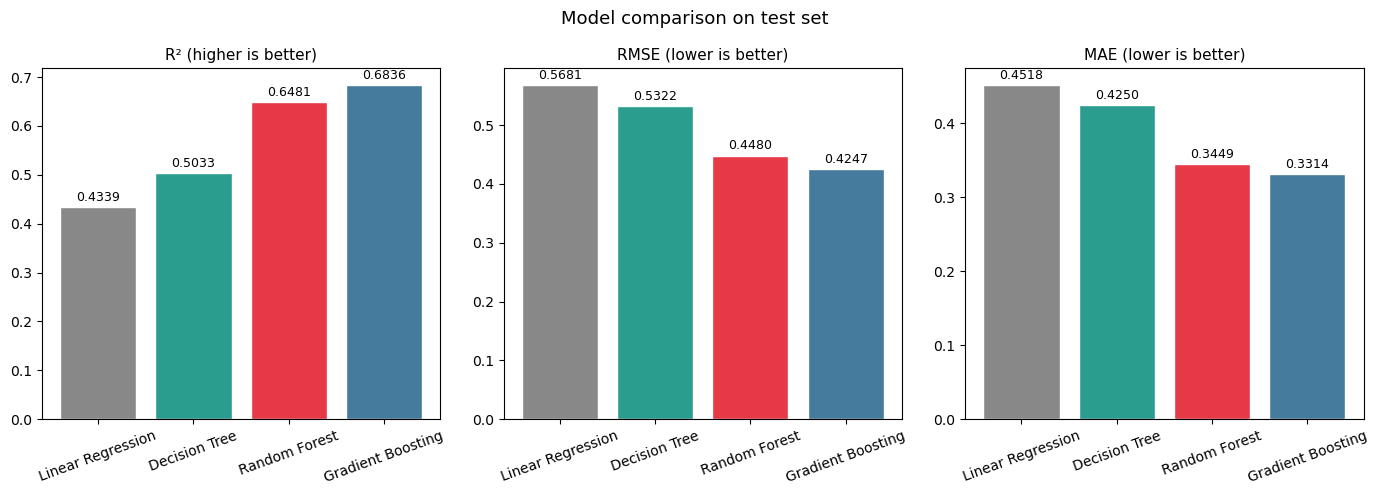

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = list(results.keys())
colors = ['#888888', '#2a9d8f', '#e63946', '#457b9d']

metrics = [('R²', 'higher is better'), ('RMSE', 'lower is better'), ('MAE', 'lower is better')]

for ax, (metric, note) in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white')
    ax.set_title(f'{metric} ({note})', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model comparison on test set', fontsize=13)
plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature importance
Which features drive predictions the most?

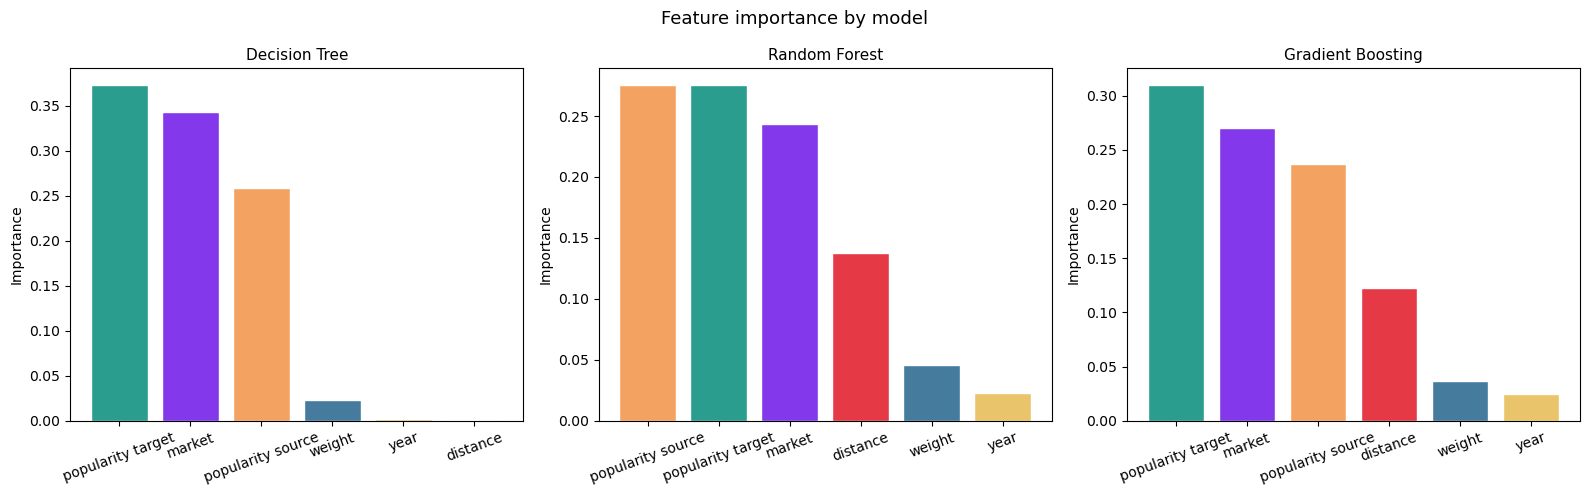


=== Gradient Boosting feature importance (ranked) ===
  popularity target 0.3098  (31.0%)
  market          0.2698  (27.0%)
  popularity source 0.2372  (23.7%)
  distance        0.1225  (12.2%)
  weight          0.0365  (3.7%)
  year            0.0242  (2.4%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tree_models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
feature_labels = ['distance', 'popularity source', 'popularity target', 'weight', 'market', 'year']
colors_fi = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d', '#8338ec', '#e9c46a']

for ax, name in zip(axes, tree_models):
    model = results[name]['model']
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    ax.bar([feature_labels[i] for i in sorted_idx],
           [importances[i] for i in sorted_idx],
           color=[colors_fi[i] for i in sorted_idx],
           edgecolor='white')
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('Importance')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Feature importance by model', fontsize=13)
plt.tight_layout()
# plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=== Gradient Boosting feature importance (ranked) ===')
gb_imp = results['Gradient Boosting']['model'].feature_importances_
for feat, imp in sorted(zip(feature_labels, gb_imp), key=lambda x: -x[1]):
    print(f'  {feat:<15} {imp:.4f}  ({imp*100:.1f}%)')

## 5. Predicted vs actual (best model)

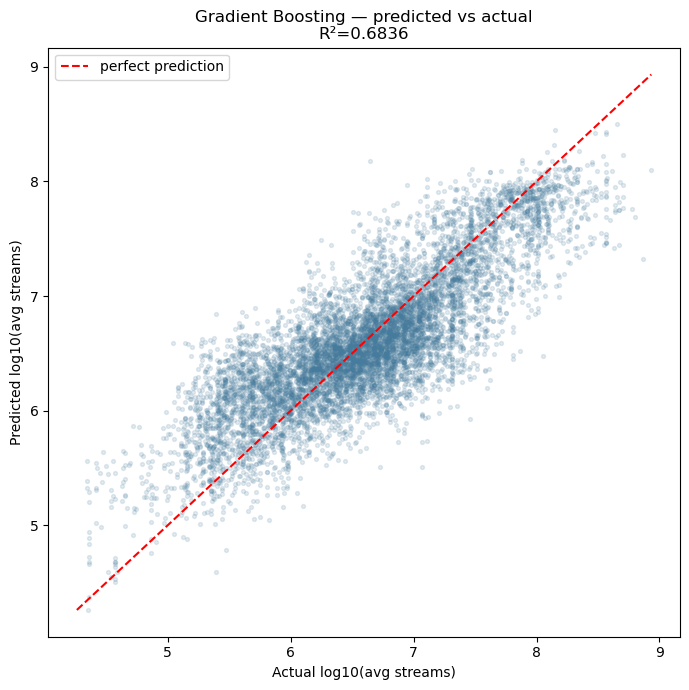

In [22]:
best_model_name = max(results, key=lambda k: results[k]['R²'])
y_pred_best = results[best_model_name]['y_pred']

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_best, alpha=0.15, s=8, color='#457b9d')

lims = [min(y_test.min(), y_pred_best.min()),
        max(y_test.max(), y_pred_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='perfect prediction')
ax.set_xlabel('Actual log10(avg streams)')
ax.set_ylabel('Predicted log10(avg streams)')
ax.set_title(f'{best_model_name} — predicted vs actual\nR²={results[best_model_name]["R²"]:.4f}')
ax.legend()
plt.tight_layout()
# plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distance importance — isolated view
The key thesis question: how much does distance alone contribute,
vs genre popularity?

distance only                  R²=0.0106
popularity only                R²=0.5072
distance + popularity          R²=0.5168
all features                   R²=0.6481

Key insight: how much does distance add on top of popularity alone?
  Popularity only:           R²=0.5072
  Distance + popularity:     R²=0.5168
  Gain from adding distance: +0.0096


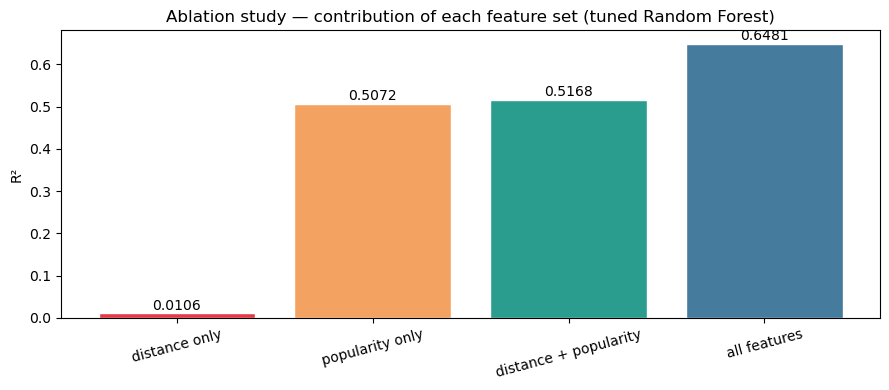

In [23]:
feature_sets = {
    'distance only':         ['distance'],
    'popularity only':       ['log_popularity_source', 'log_popularity_target'],
    'distance + popularity': ['distance', 'log_popularity_source', 'log_popularity_target'],
    'all features':          FEATURES,
}

# use the tuned Random Forest params for consistency
tuned_rf = results['Random Forest']['model']
tuned_params = tuned_rf.get_params()

ablation_results = []
for label, feats in feature_sets.items():
    m = RandomForestRegressor(
        n_estimators=tuned_params['n_estimators'],
        max_depth=tuned_params['max_depth'],
        min_samples_split=tuned_params['min_samples_split'],
        min_samples_leaf=tuned_params['min_samples_leaf'],
        max_features=tuned_params['max_features'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    m.fit(X_train[feats], y_train)
    y_pred = m.predict(X_test[feats])
    r2 = r2_score(y_test, y_pred)
    ablation_results.append({'Feature set': label, 'R²': round(r2, 4)})
    print(f'{label:<30} R²={r2:.4f}')

print()
print('Key insight: how much does distance add on top of popularity alone?')
r2_pop  = next(r['R²'] for r in ablation_results if r['Feature set'] == 'popularity only')
r2_both = next(r['R²'] for r in ablation_results if r['Feature set'] == 'distance + popularity')
print(f'  Popularity only:           R²={r2_pop:.4f}')
print(f'  Distance + popularity:     R²={r2_both:.4f}')
print(f'  Gain from adding distance: {r2_both - r2_pop:+.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
labels     = [r['Feature set'] for r in ablation_results]
r2s        = [r['R²'] for r in ablation_results]
bar_colors = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d']
bars = ax.bar(labels, r2s, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('R²')
ax.set_title('Ablation study — contribution of each feature set (tuned Random Forest)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
# plt.savefig('ablation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Performance by market
Does the model perform differently across markets?

market    n     R²   RMSE
    ca 1261 0.4218 0.4010
    au 1042 0.3992 0.4104
    gb 1199 0.3987 0.4516
    us 1153 0.3920 0.4254
    br  609 0.3899 0.3821
global 1205 0.3889 0.4160
    jp  520 0.3780 0.4134
    de 1011 0.3403 0.4569
    fr  733 0.2929 0.4471


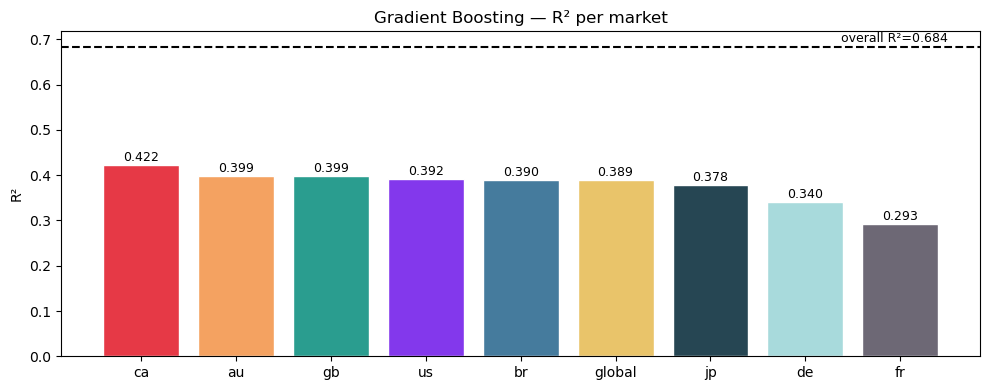

Exception ignored in: <function ResourceTracker.__del__ at 0x1062c1bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105a21bc0>
Traceback (most recent call last):
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/mikolajandrzejewski/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [E

In [24]:
best_model = results[best_model_name]['model']
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = results[best_model_name]['y_pred']
test_df['market'] = df.loc[X_test.index, 'market'].values

market_results = []
for market, group in test_df.groupby('market'):
    r2   = r2_score(group['y_true'], group['y_pred'])
    rmse = np.sqrt(mean_squared_error(group['y_true'], group['y_pred']))
    market_results.append({'market': market, 'n': len(group),
                           'R²': round(r2, 4), 'RMSE': round(rmse, 4)})

mdf = pd.DataFrame(market_results).sort_values('R²', ascending=False)
print(mdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors_m = ['#e63946', '#f4a261', '#2a9d8f', '#8338ec',
                '#457b9d', '#e9c46a', '#264653', '#a8dadc', '#6d6875']
bars = ax.bar(mdf['market'], mdf['R²'], color=bar_colors_m[:len(mdf)], edgecolor='white')
for bar, val in zip(bars, mdf['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(results[best_model_name]['R²'], color='black',
           linewidth=1.5, linestyle='--')
ax.text(len(mdf)-0.5, results[best_model_name]['R²'] + 0.003,
        f'overall R²={results[best_model_name]["R²"]:.3f}',
        ha='right', va='bottom', fontsize=9)
ax.set_ylabel('R²')
ax.set_title(f'{best_model_name} — R² per market')
plt.tight_layout()
# plt.savefig('market_performance.png', dpi=150, bbox_inches='tight')
plt.show()